# Spectroscopy Module Usage Examples
This notebook demonstrates how to use the refactored Python modules in the `spectroscopy` package.

In [1]:
from pathlib import Path

from spectroscopy import (
    apply_luminous_efficacy,
    calibrate_reflectance,
    compute_irradiance_and_lux,
    discover_image_sequence,
    extract_mapping_line,
    fft_image_sequence,
    find_peak_wavenumbers,
    load_fluorolog_folder,
    load_ftir_spectra,
    load_image_sequence,
    load_light_spectrum,
    load_luminous_efficacy,
    load_perkinelmer_results,
    normalize_and_filter_ftir,
    plot_fluorolog_overview,
    preprocess_raman_mapping_line,
    preprocess_raman_spectrum,
    read_raman_spectrum,
)
from spectroscopy.plotting import (
    add_vertical_markers,
    create_figure,
    finalize_axis,
    plot_dataframe_columns,
    plot_perkin_data_overview,
)

## Raman Spectrum

In [ ]:
raman_file = Path(r"C:/path/to/raman_spectrum.txt")
spectrum = read_raman_spectrum(raman_file)
baseline, filtered = preprocess_raman_spectrum(
    spectrum,
    wav_lower_limit=2750,
    wav_upper_limit=3150,
)
baseline.head(), filtered.head()

## Raman Mapping (Single Y-Line)

In [ ]:
mapping_file = Path(r"C:/path/to/raman_map.txt")
raw_data, x_points, wav_points = extract_mapping_line(
    mapping_file,
    y_value=25041.7,
    x_min=-2410,
    wav_lower_limit=1100,
)
mapping = preprocess_raman_mapping_line(
    raw_data,
    x_points=x_points,
    y_value=25041.7,
    wav_points=wav_points,
)
mapping.filtered.shape

## PerkinElmer Results and Reflectance Calibration

In [ ]:
sample_folder = Path(r"C:/path/to/perkinelmer_data")
sample_names, perkin_data = load_perkinelmer_results(sample_folder)
fig, ax, selected_columns = plot_perkin_data_overview(perkin_data)

In [ ]:
calibrated, calibration = calibrate_reflectance(
    perkin_data,
    dark_standard_column="2.5% DR Standard",
    white_standard_column="99% DR Standard",
    dark_reference_csv=Path(r"C:/path/to/22011925.csv"),
    white_reference_csv=Path(r"C:/path/to/22011924.csv"),
)
sample_names.head(), calibrated.head()

## Fluorolog

This example loads all `.dat` files in a folder (for example, `DPAm.dat`) and plots the extracted y-traces against wavelength.

Loading DPAm.dat: filename ends with 'm', prioritizing y column 'S1c'.
Using columns for DPAm.dat: x='Wavelength', y='S1c'.
Loading DPAx.dat: filename ends with 'x', prioritizing y column 'S1cR1c'.
Using columns for DPAx.dat: x='Wavelength', y='S1c / R1c'.
Loading PdOEPDPAm.dat: filename ends with 'm', prioritizing y column 'S1c'.
Using columns for PdOEPDPAm.dat: x='Wavelength', y='S1c'.
Skipping PdOEPDPAu.dat: filename does not end with 'm' or 'x'.
Loading PdOEPDPAx.dat: filename ends with 'x', prioritizing y column 'S1cR1c'.
Using columns for PdOEPDPAx.dat: x='Wavelength', y='S1c / R1c'.
Loading PdOEPm.dat: filename ends with 'm', prioritizing y column 'S1c'.
Using columns for PdOEPm.dat: x='Wavelength', y='S1c'.
Loading PdOEPx.dat: filename ends with 'x', prioritizing y column 'S1cR1c'.
Using columns for PdOEPx.dat: x='Wavelength', y='S1c / R1c'.


,file,x_column,y_column
sample,,,
DPAm,DPAm.dat,Wavelength,S1c
DPAx,DPAx.dat,Wavelength,S1c / R1c
PdOEPDPAm,PdOEPDPAm.dat,Wavelength,S1c
PdOEPDPAx,PdOEPDPAx.dat,Wavelength,S1c / R1c
PdOEPm,PdOEPm.dat,Wavelength,S1c
PdOEPx,PdOEPx.dat,Wavelength,S1c / R1c


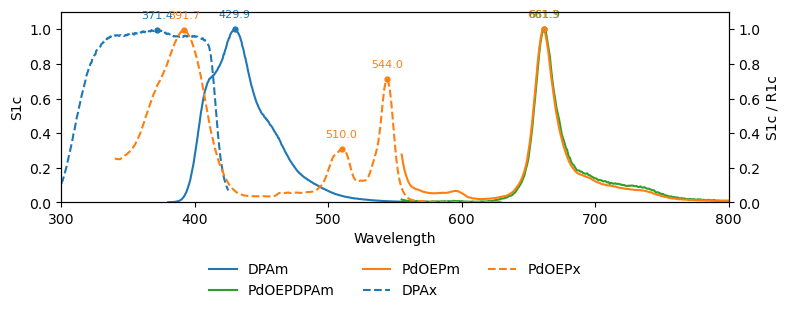

In [2]:
fluorolog_folder = Path(r"Z:\\Fluorolog\\Takashi\\LSMRs\\260326_DPA_PdOEP_PVAc")
file_table, fluorolog_data = load_fluorolog_folder(fluorolog_folder)
fig, ax, selected_columns = plot_fluorolog_overview(
    fluorolog_data,
    ignore_files=["PdOEPDPAx"],
    max_peaks_per_trace=None,
    peak_prominence=0.05,
    peak_fit_window_points=11,
    label_peaks=True,
    normalize=True,
)
file_table

## FTIR

In [ ]:
ftir_folder = Path(r"C:/path/to/ftir")
ftir_files = [
    "LWEL-acry-WG-lat-1_3mW-220225",
    "LWEL-acry-WG-lat-1_3mW-220225-2",
]
ftir_data = load_ftir_spectra(ftir_folder, ftir_files)
ftir_processed = normalize_and_filter_ftir(ftir_data)
peak_positions = find_peak_wavenumbers(ftir_processed[ftir_files[0]], prominence=0.01)
peak_positions[:10]

## Power Spectrum to Lux

In [ ]:
light_file = Path(r"C:/path/to/light_spectrum.txt")
efficacy_file = Path(r"C:/path/to/Luminous_Efficacy_Tables.csv")

meta, spectrum = load_light_spectrum(light_file)
efficacy = load_luminous_efficacy(efficacy_file)
with_lumen = apply_luminous_efficacy(spectrum, efficacy)
with_illum, int_lux, int_irr = compute_irradiance_and_lux(with_lumen)
int_lux, int_irr

## LWEL Camera Image Sequence

In [ ]:
camera_folder = Path(r"C:/path/to/image_sequence")
prefix = "220225_Epoxide_2022-02-25-114524"
count = discover_image_sequence(camera_folder, prefix)
images = load_image_sequence(camera_folder, prefix, count)
fft_images = fft_image_sequence(images)
count, list(fft_images.keys())[:5]